# Stacking 

Stacking은 **여러 개의 서로 다른 예측 모델(=base learner, 기본 모델)** 의 예측 결과를 **다시 하나의 모델(=meta learner, 메타 모델)이 학습** 해서 최종 예측을 하는 방법이다.

- 일반적인 Voting이나 Averaging은 기본 모델들의 예측 결과를 단순 집계(평균, 다수결 등)하지만,
- Stacking은 **여러 모델의 예측 결과 자체를 새로운 특성(Feature)으로 만들어, 최종 메타 모델이 학습** 하는 방식이다.

**구조**
**1단계(Base models)**: 서로 다른 여러 개의 모델(예: 로지스틱 회귀, 결정트리, SVM 등)이 각각 학습하고 예측한다.
**2단계(Meta model)**: 1단계에서 나온 예측값(각 모델의 output)을 입력 데이터로 사용해 메타 모델을 다시 학습한다.

**주로 사용하는 Base model 종류**
- 선형 모델(선형회귀, 로지스틱 회귀): 기준이 단순하고 해석이 쉬워서 비교 기준점 역할을 하기에 좋다.
- 트리 계열(결정트리, 랜덤포레스트): 비선형 패턴을 잘 잡고, 데이터 스케일링에 덜 민감하다.
- 거리 기반 모델(KNN): 가까운 샘플의 유사성을 보는 관점이 달라 다른 모델과 보완 관계를 만들기 쉽다.
- 커널 기반 모델(SVM/SVC): 복잡한 경계를 잘 나눌 수 있어, 선형/트리 모델이 놓친 패턴을 잡는 데 도움이 될 수 있다.
- 부스팅 계열(XGBoost, Gradient Boosting 등): 강한 예측 성능을 가진 경우가 많아 base learner로 자주 고려된다.

**주로 사용하는 Meta model 종류**
- 선형회귀 / 로지스틱 회귀: 구조가 단순하고 과적합 위험이 비교적 적어서 가장 많이 쓰인다.
- 랜덤포레스트 / Gradient Boosting: base model들의 예측을 다시 비선형적으로 조합하고 싶을 때 사용한다.
- Ridge / Lasso 계열: 메타 입력이 많을 때 가중치를 안정적으로 조절하는 데 도움이 된다.

즉, stacking에서는 **서로 비슷한 모델을 여러 개 쓰는 것보다, 서로 다른 관점으로 예측하는 모델을 조합하는 것** 이 더 중요할 때가 많다.

**장점**
* 서로 다른 모델이 잘하는 부분을 결합할 수 있다.
* 단일 모델보다 성능이 더 좋아질 가능성이 있다.
* base learner들의 다양성이 클수록 시너지가 날 수 있다.

**주의할 점**
* 구조가 복잡해져 해석이 어려워질 수 있다.
* 학습 시간이 더 오래 걸릴 수 있다.
* base learner들이 너무 비슷하면 큰 이득이 없을 수도 있다.

## StackingRegressor

StackingRegressor는 여러 회귀 모델의 예측값을 모아서, 그 예측값을 다시 최종 회귀 모델이 학습하는 방식의 앙상블 객체이다.

- base learner: 각각의 회귀 모델이 먼저 예측을 만든다.
- final_estimator: base learner들의 예측을 다시 입력으로 받아 최종 예측을 만든다.
- 회귀 문제이므로 최종 출력은 연속형 값이다.

즉, 여러 회귀 모델의 예측을 단순 평균하지 않고, 어떤 모델의 예측을 얼마나 더 믿을지를 최종 모델이 다시 학습한다고 이해하면 된다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# 캘리포니아 집값 예측
from sklearn.model_selection import train_test_split
df = pd.read_csv('data/california_housing.csv')

# 데이터 구조 확인
print(df.head())
print(df.info())

# 타겟과 피처 분리
X = df.drop('MedHouseVal', axis=1).to_numpy()
y = df['MedHouseVal'].to_numpy()

# 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

In [9]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

base_learners = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('knn', KNeighborsRegressor())
]

meta_learner = RandomForestRegressor(random_state=42)

stack_reg = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=True                    # 메타모델이 원본 학습 데이터도 학습할지 여부
)

stack_reg.fit(X_train, y_train)

print('train r^2:', stack_reg.score(X_train, y_train))
print('test r^2:', stack_reg.score(X_test, y_test))

train r^2: 0.8950337429820394
test r^2: 0.781232577868832


### 스태킹은 내부적으로 무엇을 보는가?

단일 모델은 원본 특성만 보고 바로 예측한다.  
하지만 스태킹은 base model들의 예측 결과를 한 번 더 모아서 meta model에 전달한다.

- 개별 base learner 성능
- stacking이 만들어낸 중간 입력값(transform 결과)
를 함께 확인해 본다.

이때 `passthrough=True` 이므로, 메타 모델은 base learner들의 예측값뿐 아니라 원본 특성도 함께 입력으로 받는다.

In [10]:
# 개별 base learner와 stacking 비교
for name, model in base_learners:
    model.fit(X_train, y_train)
    print(f'[[{name}]]: train r^2 : {model.score(X_train, y_train)}')
    print(f'[[{name}]]: test r^2 : {model.score(X_test, y_test)}')
    print()

print(f'[[stacking]]: train r^2 : {stack_reg.score(X_train, y_train)}')
print(f'[[stacking]]: test r^2 : {stack_reg.score(X_test, y_test)}')

# base learner들의 예측 결과를 메타 모델 입력 형태로 변환
meta_features_reg = stack_reg.transform(X_train[:5])

print('메타모델 입력 형태:', meta_features_reg.shape)
print('메타모델 입력 데이터(앞 5행):')
print(meta_features_reg)

print("원본 특성 수:", X_train.shape[1])
print("base learner의 개수:", len(base_learners))
print("메타 모델은 각 base model의 예측 값과 원본 특성을 함께 보고 있다.")

[[lr]]: train r^2 : 0.6125511913966952
[[lr]]: test r^2 : 0.5757877060324526

[[dt]]: train r^2 : 1.0
[[dt]]: test r^2 : 0.622075845135081

[[knn]]: train r^2 : 0.45292523357436776
[[knn]]: test r^2 : 0.14631049965900345

[[stacking]]: train r^2 : 0.8950337429820394
[[stacking]]: test r^2 : 0.781232577868832
메타모델 입력 형태: (5, 11)
메타모델 입력 데이터(앞 5행):
[[ 1.93725845e+00  1.03000000e+00  1.26160000e+00  3.25960000e+00
   3.30000000e+01  5.01765650e+00  1.00642055e+00  2.30000000e+03
   3.69181380e+00  3.27100000e+01 -1.17030000e+02]
 [ 2.48910616e+00  3.82100000e+00  2.51360000e+00  3.81250000e+00
   4.90000000e+01  4.47354497e+00  1.04100529e+00  1.31400000e+03
   1.73809524e+00  3.37700000e+01 -1.18160000e+02]
 [ 2.64735483e+00  1.72600000e+00  1.62660000e+00  4.15630000e+00
   4.00000000e+00  5.64583333e+00  9.85119048e-01  9.15000000e+02
   2.72321429e+00  3.46600000e+01 -1.20480000e+02]
 [ 1.56589492e+00  9.34000000e-01  1.91000000e+00  1.94250000e+00
   3.60000000e+01  4.00281690e+00  1

## StackingClassifier

StackingClassifier는 여러 분류 모델의 예측 결과를 모아서, 그 결과를 다시 최종 분류 모델이 학습하는 방식의 앙상블 객체이다.

- base learner: 각각의 분류 모델이 먼저 클래스 예측 또는 확률 정보를 만든다.
- final_estimator: base learner들의 예측 결과를 다시 입력으로 받아 최종 클래스를 판단한다.
- 분류 문제이므로 최종 출력은 클래스 또는 클래스 확률이다.

즉, 여러 분류 모델의 의견을 단순 다수결로 합치는 것이 아니라, 어떤 모델의 판단을 어떤 상황에서 더 신뢰할지를 최종 모델이 학습한다고 이해하면 된다.

In [11]:
from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.data, digits.target

print(X.shape, y.shape)

X[0].reshape(8, 8)

(1797, 64) (1797,)


array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

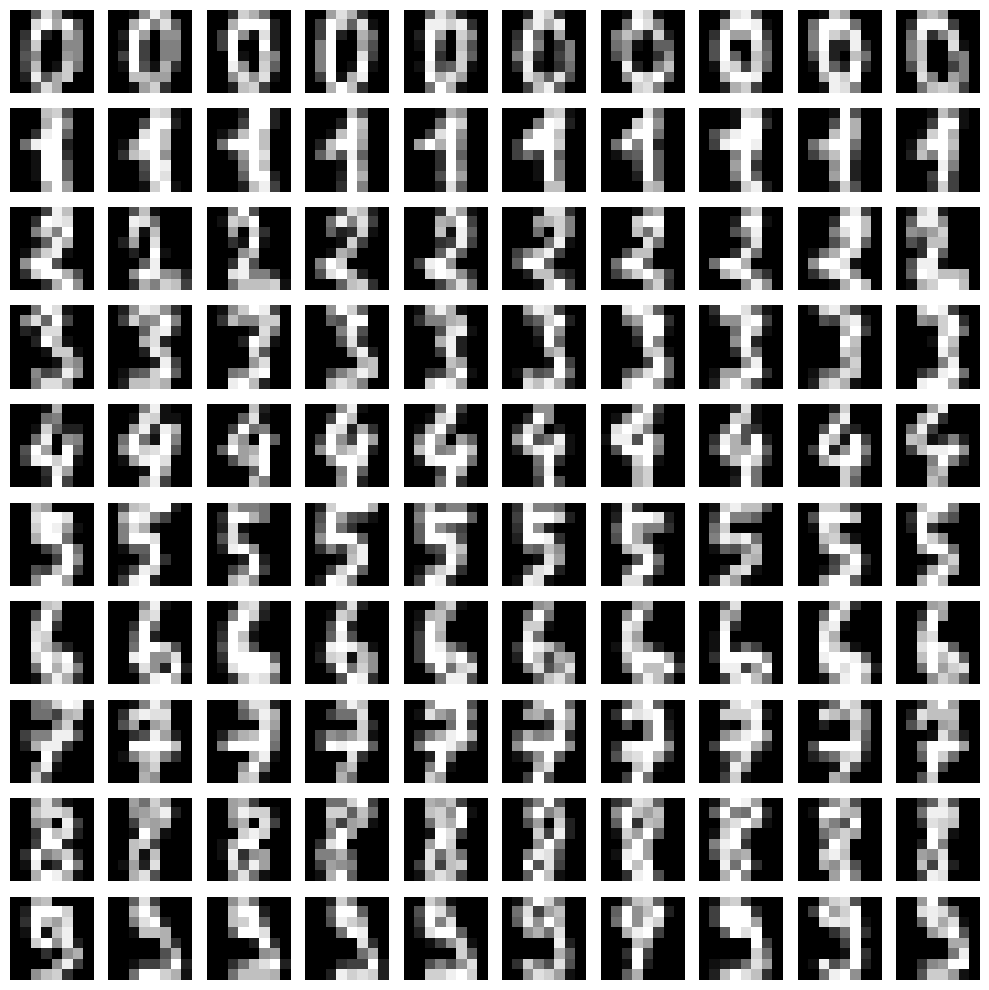

In [12]:
# 시각화

# 숫자별 10개씩 가져오기
class_images = {i:[] for i in range(10)}

# X의 이미지 데이터와 y의 정답 라벨을 한 쌍씩 묶어서 순회한다.
for img, label in zip(X, y):
    # 10개씩만 담기
    if len(class_images[label]) < 10:
        class_images[label].append(img)

# 시각화
# 여러 개의 작은 그래프 영역(축, axes)을 한 번에 생성한다.
# 10행 10열이므로 총 100개의 칸을 만든다.
fig, ax = plt.subplots(10, 10, figsize=(10, 10))

for i in range(10):
    for j in range(10):
        # imshow():
        # 2차원 배열 형태의 이미지를 화면에 출력하는 메소드이다.
        # digits 데이터는 1차원(길이 64)로 저장되어 있으므로 8x8로 다시 바꿔서 보여준다.
        ax[i, j].imshow(class_images[i][j].reshape(8, 8), cmap='gray')

        # axis('off'):
        # 각 작은 그래프의 축 눈금, 테두리 표시를 숨겨서
        # 이미지 자체만 보이도록 만든다.
        ax[i, j].axis('off')

# 여러 subplot이 겹치지 않도록 간격을 자동으로 정리한다.
plt.tight_layout()
plt.show()


In [13]:
# 데이터분할
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [17]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

base_learners = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('svc', make_pipeline(StandardScaler(), SVC(random_state=42, kernel='rbf')))
]

meta_learner = LogisticRegression(random_state=42, max_iter=1000)

stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=True
)

stack_clf.fit(X_train, y_train)

print('train accuracy:', stack_clf.score(X_train, y_train))
print('test accuracy:', stack_clf.score(X_test, y_test))

train accuracy: 1.0
test accuracy: 0.9722222222222222


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, stack_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.94      0.89      0.91        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.87      0.94      0.90        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



### 분류 스태킹은 어떤 정보를 모아서 최종 판단하는가?

분류 스태킹도 아이디어는 같다.  
단일 분류 모델은 원본 특성을 보고 바로 클래스를 예측하지만, 스태킹은 여러 분류 모델의 판단 결과를 다시 모아서 최종 분류기가 학습한다.

- 개별 base learner 성능
- stacking의 transform 결과
를 확인해서, 메타 모델이 실제로 어떤 입력을 받는지 본다.

In [19]:
# 개별 base learner와 stacking 비교
for name, model in base_learners:
    model.fit(X_train, y_train)
    print(f'[[{name}]]: train accuracy : {model.score(X_train, y_train)}')
    print(f'[[{name}]]: test accuracy : {model.score(X_test, y_test)}')
    print()

print(f'[[stacking]]: train accuracy : {stack_clf.score(X_train, y_train)}')
print(f'[[stacking]]: test accuracy : {stack_clf.score(X_test, y_test)}')

# base learner들의 예측 결과를 메타 모델 입력 형태로 변환
meta_features_clf = stack_clf.transform(X_train[:5])

print('메타모델 입력 형태:', meta_features_clf.shape)
print('메타모델 입력 데이터(앞 5행):')
print(meta_features_clf)

print("원본 특성 수:", X_train.shape[1])
print("base learner의 개수:", len(base_learners))
print("메타 모델은 각 base model의 예측 값과 원본 특성을 함께 보고 있다.")

[[dt]]: train accuracy : 1.0
[[dt]]: test accuracy : 0.825

[[knn]]: train accuracy : 0.9916492693110647
[[knn]]: test accuracy : 0.9833333333333333

[[svc]]: train accuracy : 0.9972164231036882
[[svc]]: test accuracy : 0.975

[[stacking]]: train accuracy : 1.0
[[stacking]]: test accuracy : 0.9722222222222222
메타모델 입력 형태: (5, 94)
메타모델 입력 데이터(앞 5행):
[[ 0.          0.          0.          0.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.6         0.          0.
   0.          0.4         1.77174415  2.77892638  3.81616919  7.21517496
   0.73816097  9.29732007 -0.28087438  4.87562919  6.20271055  8.25677744
   0.          0.         11.         10.         12.         14.
  11.          0.          0.          0.         16.         16.
  16.         16.          7.          0.          0.          1.
  16.         16.         16.         12.          0.          0.
   0.          1.          5.          2

## 정리
1. Stacking은 여러 base learner의 예측 결과를 다시 meta learner가 학습하는 앙상블 방식이다.
2. Voting처럼 단순 평균이나 다수결을 내는 것이 아니라, 어떤 모델의 예측을 더 신뢰할지 최종 모델이 학습한다.
3. StackingRegressor는 여러 회귀 모델의 예측값을 조합해 더 안정적인 연속형 값을 예측한다.
4. StackingClassifier는 여러 분류 모델의 판단 결과를 조합해 최종 클래스를 예측한다.
5. `passthrough=True`일 때는 base learner의 예측값뿐 아니라 원본 특성도 함께 meta learner에 전달된다.
6. 따라서 stacking은 서로 다른 관점의 모델을 조합할수록 장점이 커질 수 있지만, 구조가 복잡해지고 학습 시간이 늘어날 수 있다.